# Notebook for experimenting different toy stellar wind models for modeling X-Ray Light Curves

In [1]:
from plot_results import *
from chandra_phase_analysis import *
from compute_flux_vs_nH import *
from xrb_lightcurve import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## ObsID 15803 in Soft band (0.5-2.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/soft/single
Removed 131 zero/NaN flux data points (1367 remaining)


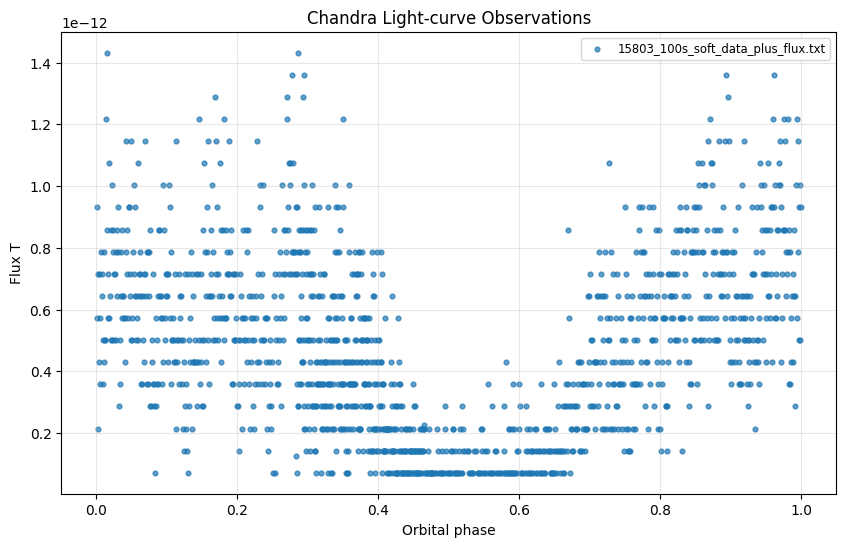

In [2]:
# Plot soft band LC
obs_column = "flux_t"
time_column = "t_raw"
data = load_data("./data/IC_10_X1_LC_CIAO/soft/single", obs_column = obs_column, time_column = time_column)
n_before = len(data)
data_df = data[(data['rate'] != 0) & (data['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(data_df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(data_df)} remaining)")
plot_phase(data_df, None, obs_column_name = obs_column)

### Smoothly Broken Power-law wind

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 4.960


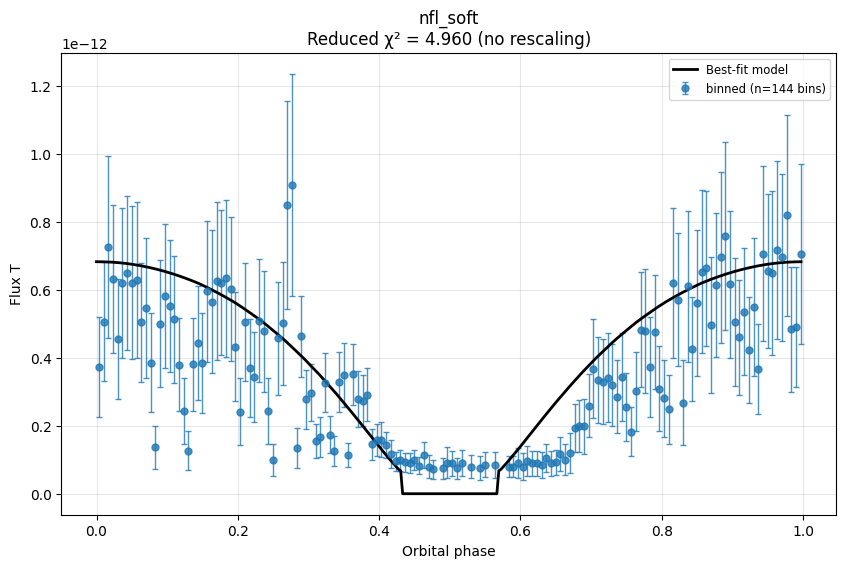

In [3]:
# Smooth powerlaw wind model
wind_params = {"Rb": 24, "p": 3, "Delta": 1}
sim_df = simulate_lightcurve(
        r=0.16,
        R=8,
        d1=8.2,
        d2=8.3,
        gma0=-90,
        i0=15,
        dth=1,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_soft.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="smooth_pl",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, scale, chi2 = fit_simulation(df, sim_df, sim_columns[0], rescale=False)
plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2,
            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

### Velocity based density model

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 26.718


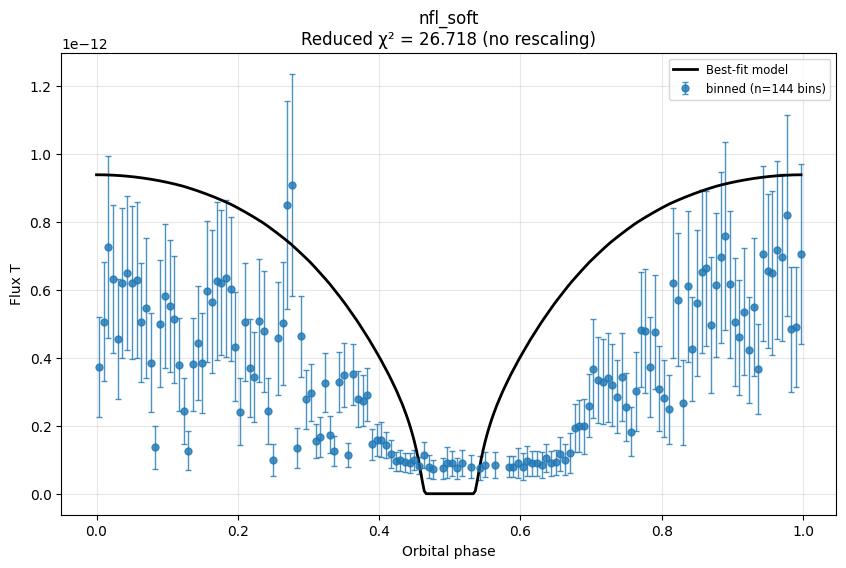

In [19]:
# Beta law wind model
R = 8
wind_params = {"beta": 0.5, "H": 1.0, "R_star": R}
sim_df = simulate_lightcurve(
        r=0.01,
        R=R,
        d1=11,
        d2=8,
        gma0=-90,
        i0=22,
        dth=1,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_soft.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="beta_law",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, scale, chi2 = fit_simulation(df, sim_df, sim_columns[0], rescale=False)
plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2,
            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

### Inner confinement or compression model

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 5.338


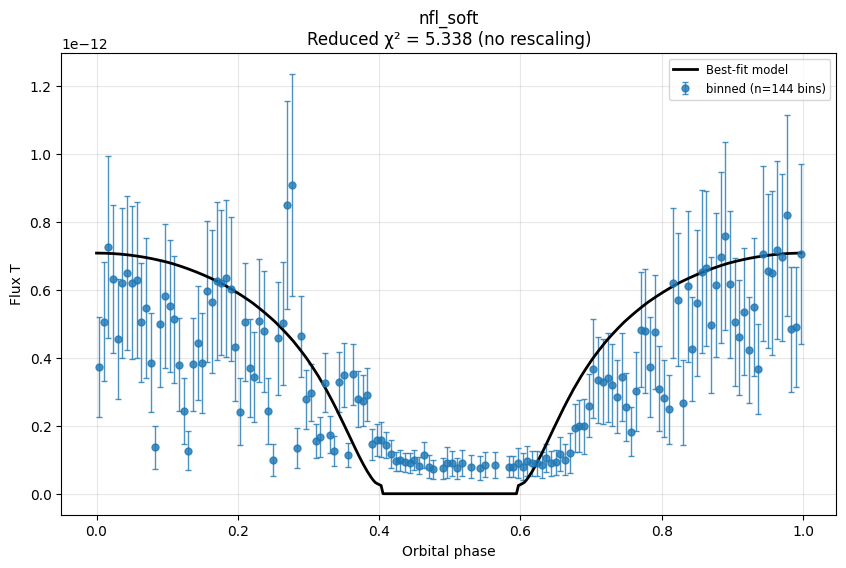

In [7]:
# Confinement wind model
R = 2.620185
wind_params = {"fconf": 10.0, "ell": 0.5, "R_star": R}
sim_df = simulate_lightcurve(
        r=0.074665,
        R=R,
        d1=2.23,
        d2=1.70,
        gma0=-90,
        i0=22,
        dth=1,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_soft.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="confinement",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, scale, chi2 = fit_simulation(df, sim_df, sim_columns[0], rescale=False)
plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2,
            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)